# Pauli Operators and Qiskit `Pauli` Class

Pauli operators form the foundation of quantum computing. They are single-qubit operators that generalize to multi-qubit systems via tensor products.
___

### 1. Single-Qubit Pauli Operators

The Pauli matrices are:


$$    
I =
\begin{pmatrix}
1 & 0 \\
0 & 1
\end{pmatrix}, \quad
X =
\begin{pmatrix}
0 & 1 \\
1 & 0
\end{pmatrix}, \quad
Y =
\begin{pmatrix}
0 & -i \\
i & 0
\end{pmatrix}, \quad
Z =
\begin{pmatrix}
1 & 0 \\
0 & -1
\end{pmatrix}
$$


These operators are Hermitian, unitary, and form a basis for all single-qubit operators.

### 2. Multi-Qubit Pauli Operators

An n-qubit Pauli operator is:

$$
P = (-i)^q \cdot P_{n-1} \otimes \cdots \otimes P_0
$$

where:
- $P_i \in \{I, X, Y, Z\}$
- $q \in \mathbb{Z}_4 = \{0,1,2,3\}$

Example:

$$
-iXYZ = (-i)^1 \cdot X \otimes Y \otimes Z
$$

***Note:*** Qubit 0 corresponds to the **rightmost** character.

### 3. Key Properties of Pauli Operators


$$
X^2 = Y^2 = Z^2 = I
$$


$$
\text{Eigenvalues of Pauli operators} = \pm 1
$$


$$
P^\dagger = P, \quad P^2 = I
$$


Pauli operators form a group under multiplication (up to phase).



Pauli operators either **commute** or **anticommute**.

$$
[X, Y] = 2iZ, \quad [Y, Z] = 2iX, \quad [Z, X] = 2iY
$$

$$
\{X, Y\} = 0, \quad \{Y, Z\} = 0, \quad \{Z, X\} = 0
$$


$$
XY = iZ,\quad YX = -iZ
$$

$$
YZ = iX,\quad ZY = -iX
$$

$$
ZX = iY,\quad XZ = -iY
$$


Two Pauli strings:
- **Commute** if they differ on an even number of positions (ignoring I)
- **Anticommute** if they differ on an odd number of positions

Example:
- $X \otimes Z$ and $Z \otimes X$ commute
- $X$ and $Z$ anticommute

___

### Pauli operators in Qiskit

Qiskit represents a Pauli operator using:

- Binary vector $z \in \mathbb{Z}_2^n$
- Binary vector $x \in \mathbb{Z}_2^n$
- Phase $q \in \mathbb{Z}_4$


$$
P = (-i)^{q + z \cdot x} Z^z X^x
$$

Thus, operations are not matrix-based but rather as efficient **symplectic form** given above.

### Mapping

| z | x | Operator |
|--|--|--|
| 0 | 0 | I |
| 0 | 1 | X |
| 1 | 0 | Z |
| 1 | 1 | Y |

In [1]:
from qiskit.quantum_info import Pauli
import numpy as np

In [16]:
## Initialization of Pauli Objects
P = Pauli('XYZ')
print(P)

## Initialization of Pauli Objects with a phase 
P = Pauli('-iXYZ')
print(P)


print('P[0] =', repr(P[0]))
print('P[1] =', repr(P[1]))
print('P[2] =', repr(P[2]))
print('P[:] =', repr(P[:]))
print('P[::-1] =', repr(P[::-1]))

XYZ
-iXYZ
P[0] = Pauli('Z')
P[1] = Pauli('Y')
P[2] = Pauli('X')
P[:] = Pauli('XYZ')
P[::-1] = Pauli('ZYX')


#### Note:  Qubit-0 corresponds to the right-most Pauli character. For example 'XYZ' represents $ X \otimes Y \otimes Z$ with 'Z' on qubit-0, 'Y' on qubit-1, and 'X' on qubit-2.

In [ ]:
z = np.array([1, 0, 1], dtype=bool) # 3 values implies it is for a 3 qubit Pauli operator, the first element is for the 0th qubit
x = np.array([0, 1, 1], dtype=bool)

P = Pauli((z, x, 2)) # phase q is 2
print(P)


# Acessing properties of the Pauli object
print("Number of qubits:", P.num_qubits)
print("Phase:", P.phase)
print("Z vector:", P.z)
print("X vector:", P.x)

print(str(P))        # will truncate the returned string for large numbers of qubits. The default truncation length is 50 characters.
print(P.to_label())  # no truncation done

-YXZ
Number of qubits: 3
Phase: 2
Z vector: [ True False  True]
X vector: [False  True  True]
-YXZ
-YXZ


In [15]:
# Matrix representation of the Pauli operator

P = Pauli('XZ')

print(P.to_matrix()) # basically outputs the tensor product of the X and Z matrices

# useful methods for Pauli operators
P1 = Pauli('X')
P2 = Pauli('Z')
print(P1 ^ P2)  # tensor product 
print(P1.tensor(P2))
print(P1.expand(P2))
print(P1.compose(P2)) # the compose method is used to compute the product of two Pauli operators.
print(P1.dot(P2)) # right multiplication, whereas compose is left multiplication. So P1.compose(P2) = P1 * P2 and P1.dot(P2) = P2 * P1
print("Commutes:", P1.commutes(P2))
print("Anticommutes:", P1.anticommutes(P2))

print('Inserting Pauli operator at index 1:')
print(P.insert(1, Pauli('Y')))
print('Deleting Pauli operator at index 0:')
print(P.delete([0]))


[[ 0.+0.j  0.+0.j  1.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j -1.+0.j]
 [ 1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j  0.+0.j  0.+0.j]]
XZ
XZ
ZX
iY
-iY
Commutes: False
Anticommutes: True
Inserting Pauli operator at index 1:
XYZ
Deleting Pauli operator at index 0:
X


### Evolution under Clifford

- Schrödinger picture evolves the Pauli as $`P^\prime = C.P.C^\dagger`$

In [ ]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(1)
qc.h(0)

P = Pauli('Z')
print(P.evolve(qc)) # outputs HZH = X

X


____

# Quantum Circuit

Circuits are at a low level of abstraction when building up quantum programs. They are the construct that is used to build up to higher levels of abstraction, such as the primitives of quantum computation, which accumulate data from many shots of quantum-circuit execution, along with advanced error-mitigation techniques and measurement optimizations, into well-typed classical data and error statistics.

In Qiskit, circuits can be defined in one of two regimes: an abstract circuit, which is defined in terms of virtual qubits and arbitrary high-level operations, like encapsulated algorithms and user-defined gates; a physical circuit (also called ISA circuit), which is defined in terms of the hardware qubits of one particular backend, and contains only operations that this backend natively supports. 

You convert from an abstract circuit to a physical circuit by using Qiskit’s transpilation package, of which the top-level access point is `transpile()`. If you define a circuit, where you intend the qubit indices to refer to physical qubits, you can use `QuantumCircuit.ensure_physical()` to rewrite the circuit’s metadata to ensure that Qiskit recognizes the circuit as a physical circuit, though unlike transpilation, this does not enforce that the basis-gates and hardware-coupling constraints will be respected.

In Qiskit, a quantum circuit is represented by the  `QuantumCircuit` class

#### Some Circuit concepts:


- abstract circuit

        A circuit (computational routine that defines a single execution to be taken on a QPU) defined in terms of abstract mathematical operations and virtual qubits. This is typically how you think about quantum algorithms; an abstract circuit can be made up of completely arbitrary unitary operations, measurements, and potentially real-time classical computation, with no restrictions about which qubits can interact with each other. 

        You turn an abstract circuit into a **physical circuit** (or ISA circuit) by using Qiskit’s transpilation package. Its definec interms of hardware qubits and only the quantum operations available in a particular QPU’s ISA.

- ancilla qubit

        An extra qubit that is used to help implement operations on other qubits, but whose final state is not important for the program.

- clbit

        A Qiskit-specific abbreviation meaning a single classical bit of data.

- gate

        A unitary operation on one or more qubits.

- hardware qubit

        The representation of a single qubit on a particular QPU. A hardware qubit has some physical quantum-mechanical system backing it, such as superconducting circuits; unlike a virtual qubit, it has particular coupling constraints and only certain gates can be applied to certain groups of hardware qubits.

        Qiskit does not distinguish logical qubits from any individual physical qubits when talking about hardware qubits. Both will have coupling constraints between them, only permit certain quantum operations on them, and have scheduling concerns between them. Qiskit abstracts these concerns together in the concept of hardware qubits.

- instruction set architecture (ISA)

        The abstract model of which operations are available on which sets of hardware qubits on one particular QPU.

- logical qubit

        A collection of several physical qubits that are controlled together by a QPU (from the user’s perspective) to apply real-time quantum error correction. A logical qubit is a type of hardware qubit for Qiskit.

- measurement

        The act of extracting one classical bit of a data from a single qubit state. This is an irreversible operation, and usually destroys entanglement and phase coherence between the target qubit and the rest of the system.

- physical qubit

        A controllable two-level quantum system. A QPU may expose this directly as its hardware qubit, or combine several physical qubits into a logical qubit.

- quantum processing unit (QPU)

        Hardware that runs quantum operations on quantum data. 

- real-time classical computation

        Any classical computation that can happen within the execution of a single shot of a circuit, where the results of the classical computation can affect later execution of the circuit. The amount of real-time classical computation available with particular QPUs will vary significantly dependent on many factors, such as the controlling electronics and the qubit technology in use. 

- unitary operation

        A reversible operation on a quantum state. All quantum gates are unitary operations.

- virtual qubit

        An abstract, mathematical qubit used to build an abstract circuit. Virtual qubits are how one typically thinks about quantum algorithms at a high level; we assume that all quantum gates are valid on all virtual qubits, and all virtual qubits are always connected to every other virtual qubit.

        When mapping to hardware, virtual qubits must be assigned to hardware qubits. Evaluating conditions to map a virtual circuit to a physical circuit is the job of Qiskit’s transpilation package.

##### Quantum circuit attributes

In [70]:
from qiskit.circuit import QuantumCircuit, Parameter

# -------------------------
# Basic Circuit Properties
# -------------------------
qc = QuantumCircuit(2, 2, name="Example Circuit")
qc.measure([0], [1])

print("Circuit Instructions (qc.data):")
print(qc.data)
print()

print("Circuit Name:")
print(qc.name)
print()

print("Global Phase:")
print(qc.global_phase)
print()

print("Qubit Objects:")
print(qc.qubits)
print()

print("Number of Qubits:")
print(qc.num_qubits)
print()

print("Number of Classical Bits:")
print(qc.num_clbits)
print()


# -------------------------
# Metadata Example
# -------------------------
# Arbitrary user-defined dictionary of metadata for the circuit.

# Qiskit will not examine the content of this mapping, but it will pass it through the transpiler and reattach it to the output, so you can track your own metadata.

qc = QuantumCircuit(2, 2, metadata={'experiment_type': 'Bell state experiment'})

print("Circuit Metadata:")
print(qc.metadata)
print()


# -------------------------
# Parameterized Circuit
# -------------------------
a = Parameter("a")
b = Parameter("b")
elephant = Parameter("elephant")

circuit = QuantumCircuit(1)
circuit.rx(b, 0)
circuit.rz(elephant, 0)
circuit.ry(a, 0)

print("Circuit Parameters (sorted alphabetically):")
print(circuit.parameters)
print()

print("Number of Parameters:")
print(circuit.num_parameters)

print("Ancilla qubits:", circuit.ancillas)

Circuit Instructions (qc.data):
[CircuitInstruction(operation=Instruction(name='measure', num_qubits=1, num_clbits=1, params=[]), qubits=(<Qubit register=(2, "q"), index=0>,), clbits=(<Clbit register=(2, "c"), index=1>,))]

Circuit Name:
Example Circuit

Global Phase:
0.0

Qubit Objects:
[<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>]

Number of Qubits:
2

Number of Classical Bits:
2

Circuit Metadata:
{'experiment_type': 'Bell state experiment'}

Circuit Parameters (sorted alphabetically):
ParameterView([Parameter(a), Parameter(b), Parameter(elephant)])

Number of Parameters:
3
Ancilla qubits: []


# Circuit Operations



The `qiskit.circuit.library` is a collection of valuable circuits and building blocks for algorithms. Elements in the circuit library are either `QuantumCircuits` or `Instructions`, allowing them to be easily investigated or plugged into other circuits. 




## Matrix Representation of some Common Quantum Gates

### 1. Single-Qubit Gates

#### Pauli gates- already covered above

#### Hadamard Gate
$$
H = \frac{1}{\sqrt{2}}
\begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix}
$$

#### Phase Gate (S Gate)
$$
S =
\begin{pmatrix}
1 & 0 \\
0 & i
\end{pmatrix}
$$

#### T Gate
$$
T =
\begin{pmatrix}
1 & 0 \\
0 & e^{i\pi/4}
\end{pmatrix}
$$



#### Rotation Gates

Rotation about X-axis:
$$
R_X(\theta) =
\begin{pmatrix}
\cos(\theta/2) & -i\sin(\theta/2) \\
-i\sin(\theta/2) & \cos(\theta/2)
\end{pmatrix}
$$

Rotation about Y-axis:
$$
R_Y(\theta) =
\begin{pmatrix}
\cos(\theta/2) & -\sin(\theta/2) \\
\sin(\theta/2) & \cos(\theta/2)
\end{pmatrix}
$$

Rotation about Z-axis:
$$
R_Z(\theta) =
\begin{pmatrix}
e^{-i\theta/2} & 0 \\
0 & e^{i\theta/2}
\end{pmatrix}
$$

---

### 2. Two-Qubit Gates

#### CNOT Gate
$$
\text{CNOT} =
\begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0
\end{pmatrix}
$$

---

#### Controlled-Z Gate
$$
CZ =
\begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & -1
\end{pmatrix}
$$

---

#### SWAP Gate
$$
SWAP =
\begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1
\end{pmatrix}
$$

---

## Constructing Controlled Gates (IMPORTANT)

Instead of memorizing matrices, any controlled gate can be constructed using projectors.

If control is on one qubit, a controlled unitary $CU$ is:

$$
CU = |0\rangle\langle 0| \otimes I + |1\rangle\langle 1| \otimes U
$$

where, 

$$
|0\rangle\langle 0| =
\begin{pmatrix}
1 & 0 \\
0 & 0
\end{pmatrix}
\quad
|1\rangle\langle 1| =
\begin{pmatrix}
0 & 0 \\
0 & 1
\end{pmatrix}
$$

#### Examples: 
$$
\text{CNOT} = |0\rangle\langle 0| \otimes I + |1\rangle\langle 1| \otimes X
$$

$$
CZ = |0\rangle\langle 0| \otimes I + |1\rangle\langle 1| \otimes Z
$$


For two controls:

$$
CCU = (I - |11\rangle\langle 11|) \otimes I + |11\rangle\langle 11| \otimes U
$$



This can be generalized to any $n$ qubit control. For $n$ control qubits, define the projector onto the all-ones state:

$$
\Pi_{1^n} = |11\cdots1\rangle\langle 11\cdots1|
$$

Then the controlled unitary becomes:

$$
C^{(n)}U = (I - \Pi_{1^n}) \otimes I + \Pi_{1^n} \otimes U
$$


### More General Controls (Arbitrary Bitstring)

You can control on **any bitstring**, not just all 1s.

For a control string $b = b_1 b_2 \cdots b_n$, define:

$$
\Pi_b = |b\rangle\langle b|
$$

Then:

$$
CU = (I - \Pi_b)\otimes I + \Pi_b \otimes U
$$

#### Example: Control on Bitstring "2" (i.e., |10⟩)

Consider 2 control qubits and 1 target qubit. The value $2 = (10)_2$, so the control state is $|10\rangle$.

The projector is:
$$
\Pi_{10} = |10\rangle\langle 10| = (|1\rangle\langle 1|)\otimes(|0\rangle\langle 0|)
$$

The controlled operation is:
$$
C_{10}(U) = (I - \Pi_{10}) \otimes I + \Pi_{10} \otimes U
$$

For example for $U = X$, the matrix becomes, 

$$
C_{10}(X) =
\begin{pmatrix}
1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 1
\end{pmatrix}
$$

Only the subspace where control = $|10\rangle$ is affected. All other basis states remain unchanged.

___


### List of Standard gates on qiskit

<div style="display: flex; gap: 10px;">
  <img src="1Qgates.png" width="32%">
  <img src="2Qgates.png" width="32%">
  <img src="3Qgates.png" width="34%">
</div>

`GlobalPhaseGate(phase, label)`	: The global phase gate $e^{i\theta}$.  It does not take any qubit arguments.


In [ ]:
### Example usage

from qiskit.circuit.library import XGate
gate = XGate()
print(gate.to_matrix())             # X gate
print(gate.power(1/2).to_matrix())  # √X gate 
print(gate.control(1).to_matrix())  # CX (controlled X) gate

In [ ]:
# To see the available standard gates and operations

from qiskit.circuit.library import get_standard_gate_name_mapping

gate_name_map = get_standard_gate_name_mapping()
print("These are the available standard gates and operations:", gate_name_map)
print("********")
cx_object = gate_name_map["cx"]
print(cx_object)
print(type(cx_object))

#### Apart from gate operations, there are also some non reversibel operations like `measure`, `reset`, `PauliProductMeasurement(pauli[, label])`. 

Measure operation measures qubits on compuatational basis states and stores the result on classical registers. 

Reset operation produces no classical data but instructs hardware to return the qubit to the $\ket{0}$ state. This is assumed to happen incoherently and to collapse any entanglement.

A Pauli Product Measurement corresponds to a joint projective measurement on multiple qubits, where the measured observable is a tensor product of Pauli operators. The outcome of this measurement is a single eigenvalue, either +1 or -1 indicating the eigenstate of the Pauli product. 

**Note:** Directives are operations to the quantum stack that are meant to be interpreted by the backend or the transpiler. In general, the transpiler or backend might optionally ignore them if there is no implementation for them. Example: `barrier`

#### General gates

Gates that are variadic, meaning that the number of qubits depends on the input.

In [23]:
from qiskit.circuit.library import DiagonalGate

diagonal = DiagonalGate([1, 1j])
print(diagonal.num_qubits)

diagonal = DiagonalGate([1, 1, 1, -1])
print(diagonal.num_qubits)

1
2


<div style="display: flex; gap: 10px;">
  <img src="Generalgates.png" width="35%">
  <img src="GeneralCircuits.png" width="35%">
</div>

## Arithmetic Circuits: Adders and Multipliers

Quantum arithmetic circuits implement classical operations (like addition and multiplication) **reversibly**, which is essential for quantum computation.

---

An adder computes:

$$
|a\rangle_n |b\rangle_n \;\longrightarrow\; |a\rangle_n |a + b\rangle
$$


- This often requires **ancilla qubits** (for carry bits)
- Can be implemented using:
  - Ripple-carry (gate-based, simple)
  - QFT-based (more parallel, fewer depth in theory)


For example, a full adder:
- Takes two registers + carry-in
- Outputs sum + carry-out

---


A multiplier computes:

$$
|a\rangle_n |b\rangle_n |0\rangle \;\longrightarrow\; |a\rangle_n |b\rangle_n |a \cdot b\rangle
$$

- Built using **controlled addition applied repeatedly**
- Requires larger ancilla space
- Typically implemented via:
  - Controlled additions
  - Shift-and-add logic
  - QFT-based methods

---

#### Qiskit functionalities

<div style="display: flex; gap: 10px;">
  <img src="Add.png" width="45%">
  <img src="Multiply.png" width="45%">
</div>

### Adder example

Example: 4+3=7.

- The below code adds A+B in place, that is B changes to A+B after the adder operation. 
- Adjust the size of register B and this the classical register "result" based on size of the expected output.

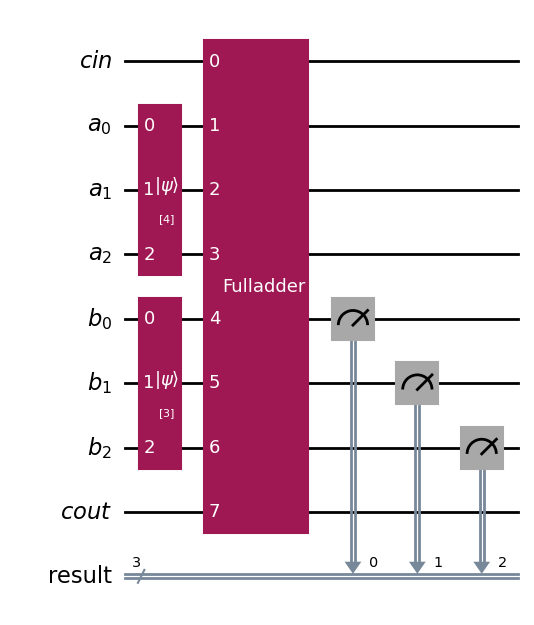

In [25]:
from qiskit.circuit.library import FullAdderGate
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

adder = FullAdderGate(3)  # Adder of 3-bit numbers

# Create the number A=2
reg_a = QuantumRegister(3, "a")
number_a = QuantumCircuit(reg_a)
number_a.initialize(4)  # Number 4; |100>

# Create the number B=3
reg_b = QuantumRegister(3, "b")
number_b = QuantumCircuit(reg_b)
number_b.initialize(3)  # Number 3; |011>

# Create a circuit to hold everything, including a classical register for
# the result
qregs = [
    QuantumRegister(1, "cin"),
    QuantumRegister(3, "a"),
    QuantumRegister(3, "b"),
    QuantumRegister(1, "cout"),
]
reg_result = ClassicalRegister(3, "result")
circuit = QuantumCircuit(*qregs, reg_result)

# Compose number initializers with the adder. Adder stores the result to
# register B, so we'll measure those qubits.
circuit = (
    circuit.compose(number_a, qubits=reg_a)
    .compose(number_b, qubits=reg_b)
    .compose(adder)
)
circuit.measure(reg_b, reg_result)
circuit.draw("mpl")

In [ ]:
from qiskit.primitives import StatevectorSampler

result = StatevectorSampler().run([circuit]).result()

print(f"Count data:\n {result[0].data.result.get_int_counts()}") # expected output is 5 (101) with high probability, since 2+3=5

Count data:
 {7: 1024}


### Multiplier Example



Example: For a 2-bit multiplier code shown below:

- First 2 qubits → register \(a\)
- Next 2 qubits → register \(b\)
- Remaining qubits → output (product)

Total qubits = input + input + output

We are only interested in the **product register**, so we measure only those qubits.

Output qubits: [4, 5, 6, 7]


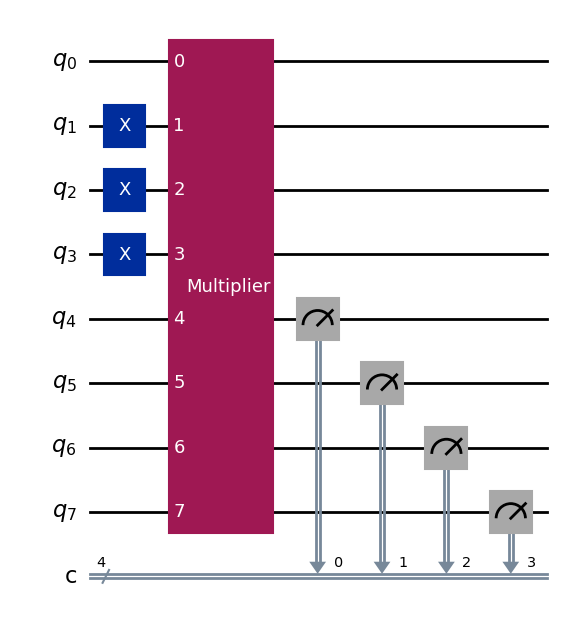

In [43]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import MultiplierGate

n = 2
mult = MultiplierGate(n)

num_qubits = mult.num_qubits

# Output register size = n (or sometimes 2n depending on implementation)
# In Qiskit MultiplierGate, output is last n qubits
output_qubits = list(range(2*n, num_qubits))

# Classical bits only for output
qc = QuantumCircuit(num_qubits, len(output_qubits))

# -------------------------
# Encode inputs
# a = 2 (10), b = 3 (11)
# -------------------------
qc.x(1)      # a = 10
qc.x(2)
qc.x(3)      # b = 11

# -------------------------
# Apply multiplier
# -------------------------
qc.append(mult, qc.qubits)

# -------------------------
# Measure ONLY output register
# -------------------------
qc.measure(output_qubits, range(len(output_qubits)))

print("Output qubits:", output_qubits)
qc.draw("mpl")

In [45]:
result = StatevectorSampler().run([qc]).result()

print(f"Count data:\n {result[0].data.c.get_int_counts()}") # expected output is 6 (110) with high probability, since 2*3=6

Count data:
 {6: 1024}


### Parametrized circuits

They are used as ansatz in a broad set of variational quantum algorithms.


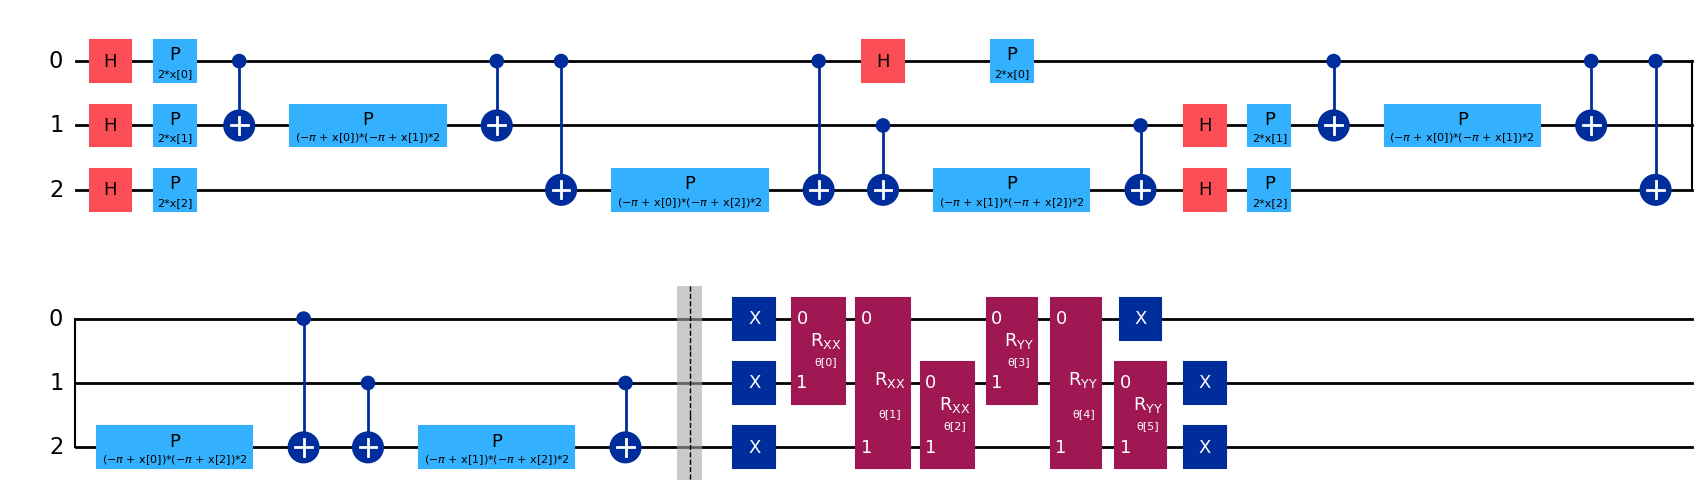

In [54]:
from qiskit.circuit.library import zz_feature_map, n_local

num_qubits = 3
ansatz= n_local(num_qubits, rotation_blocks='x', entanglement_blocks=["rxx", "ryy"], reps=1) # n_local is a simple ansatz that applies RX and RZ rotations to each qubit, followed by a layer of CNOTs. The reps parameter controls how many times this pattern is repeated.
circuit = zz_feature_map(num_qubits) # zz_feature_map is a feature map that encodes classical data into quantum states using ZZ interactions. It applies a series of RZ rotations followed by ZZ gates between pairs of qubits.
circuit.barrier()
circuit.compose(ansatz, inplace=True)

circuit.draw("mpl")

#### Other examples for ansatz and data encoding circuits supported in qiskit

<div style="display: flex; gap: 10px;">
  <img src="Ansatz.png" width="45%">
  <img src="data.png" width="50%">
</div>

## Data Preparation Circuits

Data preparation encodes classical data into a quantum state.

Given a normalized vector:
$$
\vec{x} = (x_0, x_1, \dots, x_{2^n-1})
$$

we prepare:
$$
|\psi\rangle = \sum_{i=0}^{2^n-1} x_i |i\rangle
$$

---

Expected state:
[0.5 0.5 0.5 0.5]

Obtained state:
[0.5+0.j 0.5+0.j 0.5+0.j 0.5+0.j]


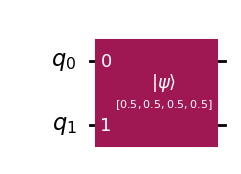

In [60]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import StatePreparation
import numpy as np
from qiskit.quantum_info import Statevector

# Define a normalized statevector (2 qubits → 4 amplitudes)
state = np.array([1, 1, 1, 1]) / 2

qc = QuantumCircuit(2)

# Initialize a qubits in a specific state. 
#   Qubit initialization is done by first resetting the qubits to |0> followed by calling :class:`~qiskit.circuit.library.StatePreparation`
qc.initialize(state, [0, 1])

# Get final statevector directly
sv = Statevector.from_instruction(qc)

print("Expected state:")
print(state)

print("\nObtained state:")
print(sv.data)

qc.draw('mpl')

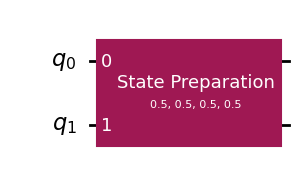

In [58]:
# Arbitrary normalized state
state = np.array([0.5, 0.5, 0.5, 0.5])

qc = QuantumCircuit(2)

prep = StatePreparation(state)

qc.append(prep, [0, 1])

qc.draw('mpl')

#### Template circuits

Templates are functions that return circuits that compute the identity. They are used at circuit optimization where matching part of the template allows the compiler to replace the match with the inverse of the remainder from the template.

##### NCT (Not-CNOT-Toffoli) template circuits are Template circuits for XGate, CXGate, and CCXGate (Toffoli) gates

In [59]:
from qiskit.circuit.library.templates import template_nct_4b_1
from qiskit.quantum_info import Operator
import numpy as np

template = template_nct_4b_1()

identity = np.identity(2 ** len(template.qubits), dtype=complex)
data = Operator(template).data
np.allclose(data, identity)  # True, template_nct_4b_1 is the identity

True

### Other advanced circuit functionalities

<div style="display: flex; gap: 10px;">
  <img src="PauliRot.png" width="40%">
  <img src="AmpFunc.png" width="40%">
  
</div>

----

<div style="display: flex; gap: 10px;">
  <img src="Bool_logic.png" width="40%">
  <img src="QFTgate.png" width="50%">

</div>

----

<div style="display: flex; gap: 10px;">
  <img src="Oracle.png" width="40%">
  <img src="Adv_arith.png" width="40%">
  
</div>